## Model 3: multimodal fusion

In [94]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import librosa
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import glob
import ast
import warnings

warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

# Create output directories
os.makedirs('../m3', exist_ok=True)
os.makedirs('../results', exist_ok=True)

Using device: mps


In [95]:
# Hyperparameters

# Data parameters
BASE_PATH = '1.0.3/training_data'
SAMPLE_RATE = 4000
DURATION = 5  # seconds per recording

# Mel spectrogram parameters
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 128

# Training parameters
N_FOLDS = 7
BATCH_SIZE = 32
LEARNING_RATE = 1e-5
NUM_EPOCHS = 200
MIN_SENSITIVITY = 0.70

# Fusion parameters
FUSION_TYPE = 'attention'  # Options: 'early', 'late', 'attention'

In [96]:
BASE_PATH = '../1.0.3/training_data'
COHORT_PATH = '../data/cohort.csv'

print(f"BASE_PATH exists: {os.path.exists(BASE_PATH)}")
print(f"COHORT_PATH exists: {os.path.exists(COHORT_PATH)}")
wav_files = glob.glob(os.path.join(BASE_PATH, '*.wav'))
print(f"\nFound {len(wav_files)} wav files")
if wav_files:
    print("Sample files:", [os.path.basename(f) for f in wav_files[:5]])

cohort = pd.read_csv(COHORT_PATH)
print(f"Total patients: {len(cohort)}")
print(f"Columns: {cohort.columns.tolist()}")
print(f"\nMurmur distribution:\n{cohort['Murmur'].value_counts()}")

BASE_PATH exists: True
COHORT_PATH exists: True

Found 3163 wav files
Sample files: ['50336_MV.wav', '50048_TV.wav', '68347_TV.wav', '50619_TV.wav', '84960_MV.wav']
Total patients: 942
Columns: ['patient_id', 'num_locations', 'sample_rate', 'recordings', 'file_path', 'Age', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'Murmur', 'Murmur locations', 'Most audible location', 'Systolic murmur timing', 'Systolic murmur shape', 'Systolic murmur grading', 'Systolic murmur pitch', 'Systolic murmur quality', 'Diastolic murmur timing', 'Diastolic murmur shape', 'Diastolic murmur grading', 'Diastolic murmur pitch', 'Diastolic murmur quality', 'Outcome', 'Campaign', 'Additional ID']

Murmur distribution:
Murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64


In [97]:
# Data parameters
SAMPLE_RATE = 4000
DURATION = 5  # seconds per recording

# Mel spectrogram parameters
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 128

# Training parameters
N_FOLDS = 5
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
MIN_SENSITIVITY = 0.70

# Fusion parameters
FUSION_TYPE = 'attention'

# Audio processing functions

In [98]:
def load_and_process_audio(wav_path, sr=SAMPLE_RATE, duration=DURATION):
    try:
        # Load audio
        signal, loaded_sr = librosa.load(wav_path, sr=sr, duration=duration)

        # Pad or truncate to fixed length
        target_length = sr * duration
        if len(signal) < target_length:
            signal = np.pad(signal, (0, target_length - len(signal)), mode='constant')
        else:
            signal = signal[:target_length]

        # Create mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            fmin=20,
            fmax=1000
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        return signal, mel_spec_db

    except Exception as e:
        print(f"Error processing {wav_path}: {e}")
        return None, None

# Process all recordings using the cohort.csv recordings column

In [99]:
waveforms = []
spectrograms = []
labels_murmur = []
patient_ids = []
locations = []
files_not_found = []
files_processed = 0

for idx, row in tqdm(cohort.iterrows(), total=len(cohort), desc="Processing patients"):
    patient_id = str(row['patient_id'])
    murmur_label = row['Murmur']

    # Parse recordings column
    try:
        recordings = ast.literal_eval(row['recordings'])
    except:
        continue

    for rec in recordings:
        wav_file = rec.get('wav_file', '')
        location = rec.get('location', '')

        # Build full path
        wav_path = os.path.join(BASE_PATH, wav_file)

        if os.path.exists(wav_path):
            waveform, mel_spec = load_and_process_audio(wav_path)

            if waveform is not None and mel_spec is not None:
                waveforms.append(waveform)
                spectrograms.append(mel_spec)
                labels_murmur.append(murmur_label)
                patient_ids.append(patient_id)
                locations.append(location)
                files_processed += 1
        else:
            files_not_found.append(wav_path)

print(f"\n✓ Processed: {files_processed} recordings")
print(f"✗ Files not found: {len(files_not_found)}")
if files_not_found:
    print(f"  Sample missing: {files_not_found[:3]}")

Processing patients: 100%|██████████| 942/942 [00:04<00:00, 195.20it/s]


✓ Processed: 3163 recordings
✗ Files not found: 0


In [100]:
                                                                                                                                    # Convert to arrays
X_waveform = np.array(waveforms)
X_melspec = np.array(spectrograms)
y_murmur = np.array(labels_murmur)
patient_ids = np.array(patient_ids)
locations = np.array(locations)

print(f"\nDataset shapes:")
print(f"  Waveforms: {X_waveform.shape}")
print(f"  Mel spectrograms: {X_melspec.shape}")
print(f"  Unique patients: {len(np.unique(patient_ids))}")
print(f"  Recording locations: {np.unique(locations)}")
print(f"\nMurmur distribution:")
print(pd.Series(y_murmur).value_counts())


Dataset shapes:
  Waveforms: (3163, 20000)
  Mel spectrograms: (3163, 64, 157)
  Unique patients: 942
  Recording locations: ['AV' 'MV' 'PV' 'Phc' 'TV']

Murmur distribution:
Absent     2391
Present     616
Unknown     156
Name: count, dtype: int64


In [101]:
# Filter out Unknown labels and encode
mask = y_murmur != 'Unknown'
X_waveform_filtered = X_waveform[mask]
X_melspec_filtered = X_melspec[mask]
y_filtered = y_murmur[mask]
patient_ids_filtered = patient_ids[mask]
locations_filtered = locations[mask]

print(f"Filtered dataset (excluding Unknown): {X_waveform_filtered.shape[0]} recordings")

# Encode labels: Absent=0, Present=1
le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)
print(f"Classes: {le.classes_}")
print(f"  {le.classes_[0]} (0): {(y_encoded == 0).sum()}")
print(f"  {le.classes_[1]} (1): {(y_encoded == 1).sum()}")

Filtered dataset (excluding Unknown): 3007 recordings
Classes: ['Absent' 'Present']
  Absent (0): 2391
  Present (1): 616


# Normalize data

In [102]:
# Normalize waveforms (z-score per sample)
def normalize_waveforms(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    std = np.where(std == 0, 1, std)
    return (X - mean) / std


X_waveform_norm = normalize_waveforms(X_waveform_filtered)

# Normalize mel spectrograms (global)
melspec_mean = X_melspec_filtered.mean()
melspec_std = X_melspec_filtered.std()
X_melspec_norm = (X_melspec_filtered - melspec_mean) / melspec_std

print(f"Waveform normalization: mean={X_waveform_norm.mean():.6f}, std={X_waveform_norm.std():.4f}")
print(f"Melspec normalization: mean={X_melspec_norm.mean():.6f}, std={X_melspec_norm.std():.4f}")

Waveform normalization: mean=0.000000, std=1.0000
Melspec normalization: mean=0.000001, std=1.0000


In [103]:
# Patient-level train/test split
unique_patients = np.unique(patient_ids_filtered)
patient_labels = np.array([y_encoded[patient_ids_filtered == p][0] for p in unique_patients])

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    stratify=patient_labels,
    random_state=42
)

train_mask = np.isin(patient_ids_filtered, train_patients)
test_mask = np.isin(patient_ids_filtered, test_patients)

X_train_waveform = X_waveform_norm[train_mask]
X_train_melspec = X_melspec_norm[train_mask]
y_train = y_encoded[train_mask]
train_patient_ids = patient_ids_filtered[train_mask]
train_locations = locations_filtered[train_mask]

X_test_waveform = X_waveform_norm[test_mask]
X_test_melspec = X_melspec_norm[test_mask]
y_test = y_encoded[test_mask]
test_patient_ids = patient_ids_filtered[test_mask]
test_locations = locations_filtered[test_mask]

print(f"Training set: {len(X_train_waveform)} recordings from {len(train_patients)} patients")
print(f"  Present: {y_train.sum()}, Absent: {(y_train == 0).sum()}")
print(f"Test set: {len(X_test_waveform)} recordings from {len(test_patients)} patients")
print(f"  Present: {y_test.sum()}, Absent: {(y_test == 0).sum()}")

Training set: 2400 recordings from 699 patients
  Present: 494, Absent: 1906
Test set: 607 recordings from 175 patients
  Present: 122, Absent: 485


# Visualize sample data

Sample with murmur:


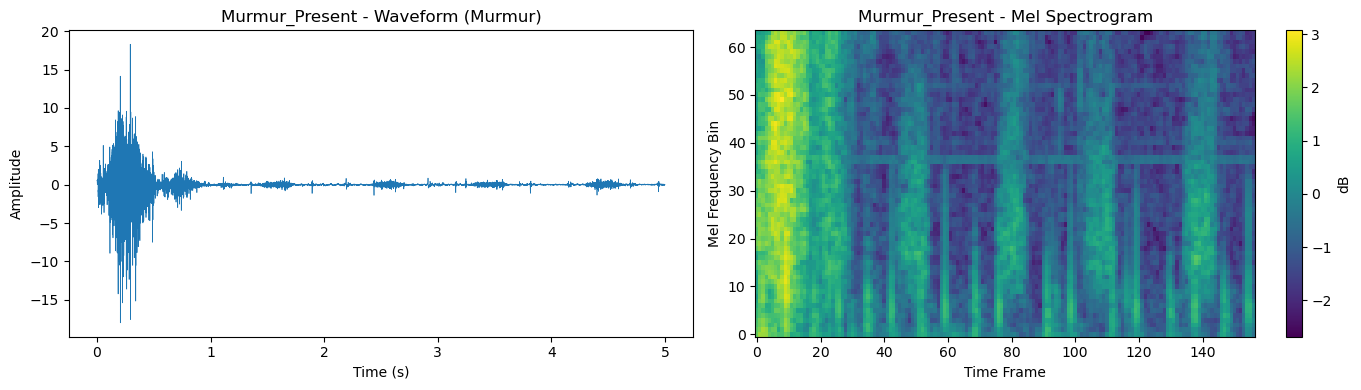


Sample without murmur:


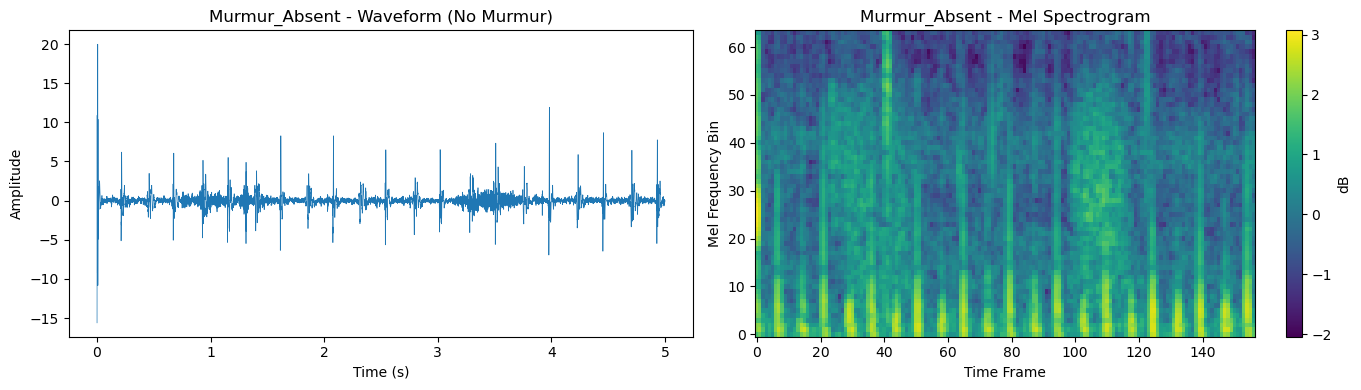

In [104]:
def plot_multimodal_sample(waveform, melspec, label, title_prefix="Sample"):
    """Visualize both modalities for a single sample."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Waveform
    time_axis = np.linspace(0, len(waveform) / SAMPLE_RATE, len(waveform))
    axes[0].plot(time_axis, waveform, linewidth=0.5)
    axes[0].set_title(f'{title_prefix} - Waveform ({"Murmur" if label else "No Murmur"})')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')

    # Mel spectrogram
    img = axes[1].imshow(melspec, aspect='auto', origin='lower', cmap='viridis')
    axes[1].set_title(f'{title_prefix} - Mel Spectrogram')
    axes[1].set_xlabel('Time Frame')
    axes[1].set_ylabel('Mel Frequency Bin')
    plt.colorbar(img, ax=axes[1], label='dB')

    plt.tight_layout()
    plt.savefig(f'../m3/{title_prefix.lower().replace(" ", "_")}_visualization.png', dpi=150)
    plt.show()


# Plot samples from each class
if y_train.sum() > 0:
    murmur_idx = np.where(y_train == 1)[0][0]
    print("Sample with murmur:")
    plot_multimodal_sample(X_train_waveform[murmur_idx], X_train_melspec[murmur_idx], 1, "Murmur_Present")

if (y_train == 0).sum() > 0:
    no_murmur_idx = np.where(y_train == 0)[0][0]
    print("\nSample without murmur:")
    plot_multimodal_sample(X_train_waveform[no_murmur_idx], X_train_melspec[no_murmur_idx], 0, "Murmur_Absent")

# Multi-Modal Dataset

In [105]:
class MultiModalDataset(Dataset):
    """
    PyTorch Dataset for multi-modal heartbeat data.
    Returns both waveform and Mel spectrogram for each sample.
    """

    def __init__(self, X_waveform, X_melspec, y, patient_ids):
        self.X_waveform = torch.tensor(X_waveform, dtype=torch.float32).unsqueeze(1)
        self.X_melspec = torch.tensor(X_melspec, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.patient_ids = patient_ids

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_waveform[idx],
            self.X_melspec[idx],
            self.y[idx],
            self.patient_ids[idx]
        )

# Model Architecture - Encoders

In [106]:
class WaveformEncoder(nn.Module):
    """1D CNN encoder for raw waveform processing."""

    def __init__(self, output_dim=128):
        super(WaveformEncoder, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=9, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x


class MelSpecEncoder(nn.Module):
    """2D CNN encoder for Mel spectrogram processing."""

    def __init__(self, output_dim=128):
        super(MelSpecEncoder, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Attention Fusion Module

In [107]:
class AttentionFusion(nn.Module):
    """Attention-based fusion module."""

    def __init__(self, feature_dim=128):
        super(AttentionFusion, self).__init__()

        self.attention = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.Tanh(),
            nn.Linear(feature_dim, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, waveform_features, melspec_features):
        combined = torch.cat([waveform_features, melspec_features], dim=1)
        attention_weights = self.attention(combined)

        waveform_weighted = waveform_features * attention_weights[:, 0:1]
        melspec_weighted = melspec_features * attention_weights[:, 1:2]

        fused = waveform_weighted + melspec_weighted
        return fused, attention_weights

# Full Multi-Modal Fusion Network

In [108]:
class MultiModalFusionNet(nn.Module):
    """Multi-modal fusion network for heart murmur detection."""

    def __init__(self, feature_dim=128, fusion_type='attention'):
        super(MultiModalFusionNet, self).__init__()

        self.fusion_type = fusion_type

        # Encoders
        self.waveform_encoder = WaveformEncoder(output_dim=feature_dim)
        self.melspec_encoder = MelSpecEncoder(output_dim=feature_dim)

        # Fusion
        if fusion_type == 'attention':
            self.fusion = AttentionFusion(feature_dim=feature_dim)
            classifier_input = feature_dim
        elif fusion_type == 'early':
            classifier_input = feature_dim * 2
        elif fusion_type == 'late':
            self.waveform_head = nn.Sequential(
                nn.Linear(feature_dim, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
            )
            self.melspec_head = nn.Sequential(
                nn.Linear(feature_dim, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
            )
            self.fusion_weight = nn.Parameter(torch.tensor([0.5]))
            classifier_input = None

        # Classifier
        if fusion_type != 'late':
            self.classifier = nn.Sequential(
                nn.Linear(classifier_input, 64),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(64, 1)
            )

        self.last_attention_weights = None

    def forward(self, waveform, melspec):
        waveform_feat = self.waveform_encoder(waveform)
        melspec_feat = self.melspec_encoder(melspec)

        if self.fusion_type == 'attention':
            fused, attn = self.fusion(waveform_feat, melspec_feat)
            self.last_attention_weights = attn.detach()
            output = self.classifier(fused)
        elif self.fusion_type == 'early':
            fused = torch.cat([waveform_feat, melspec_feat], dim=1)
            output = self.classifier(fused)
        elif self.fusion_type == 'late':
            w_pred = self.waveform_head(waveform_feat)
            m_pred = self.melspec_head(melspec_feat)
            w = torch.sigmoid(self.fusion_weight)
            output = w * w_pred + (1 - w) * m_pred

        return output

In [109]:
# Test model architecture
print("Testing model architecture...")
waveform_length = X_train_waveform.shape[1]
melspec_shape = X_train_melspec.shape[1:]

print(f"Waveform length: {waveform_length}")
print(f"Mel spectrogram shape: {melspec_shape}")

test_waveform = torch.randn(2, 1, waveform_length).to(device)
test_melspec = torch.randn(2, 1, *melspec_shape).to(device)

model = MultiModalFusionNet(fusion_type=FUSION_TYPE).to(device)
output = model(test_waveform, test_melspec)
print(f"Output shape: {output.shape}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

del model, test_waveform, test_melspec

Testing model architecture...
Waveform length: 20000
Mel spectrogram shape: (64, 157)
Output shape: torch.Size([2, 1])
Total parameters: 425,539


# Helper Functions

In [110]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0
    for waveform, melspec, labels, _ in dataloader:
        waveform = waveform.to(device)
        melspec = melspec.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(waveform, melspec).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * waveform.size(0)
    return total_loss / len(dataloader.dataset)


def get_predictions(model, dataloader):
    model.eval()
    all_outputs, all_labels, all_pids, all_attn = [], [], [], []

    with torch.no_grad():
        for waveform, melspec, labels, pids in dataloader:
            waveform = waveform.to(device)
            melspec = melspec.to(device)
            outputs = torch.sigmoid(model(waveform, melspec)).squeeze().cpu().numpy()

            if outputs.ndim == 0:
                outputs = np.array([outputs.item()])

            all_outputs.extend(outputs)
            all_labels.extend(labels.numpy())
            all_pids.extend(pids)

            if hasattr(model, 'last_attention_weights') and model.last_attention_weights is not None:
                all_attn.extend(model.last_attention_weights.cpu().numpy())

    return np.array(all_outputs), np.array(all_labels), np.array(all_pids), np.array(all_attn) if all_attn else None


def aggregate_to_patient_level(preds, labels, patient_ids):
    df = pd.DataFrame({'patient_id': patient_ids, 'pred': preds, 'label': labels})
    return df.groupby('patient_id').agg({'pred': 'max', 'label': 'max'}).reset_index()


def compute_metrics(y_true, y_pred_proba, threshold):
    y_pred = (y_pred_proba >= threshold).astype(int)

    try:
        auc = roc_auc_score(y_true, y_pred_proba)
    except:
        auc = 0.5

    try:
        auprc = average_precision_score(y_true, y_pred_proba)
    except:
        auprc = 0.0

    try:
        f1 = f1_score(y_true, y_pred)
    except:
        f1 = 0.0

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {'auc': auc, 'auprc': auprc, 'f1': f1, 'sensitivity': sens,
            'specificity': spec, 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn}

# Cross-validation setup

In [111]:
train_meta = pd.DataFrame({
    'patient_id': train_patient_ids,
    'label': y_train
}).drop_duplicates(subset='patient_id')

print(f"Training patients for CV: {len(train_meta)}")
print(f"  With murmur: {int(train_meta['label'].sum())}")
print(f"  Without murmur: {int((train_meta['label'] == 0).sum())}")

Training patients for CV: 699
  With murmur: 143
  Without murmur: 556


# Cross-validation training

In [112]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

cv_val_probs, cv_val_labels, cv_val_pids = [], [], []
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_meta, train_meta['label'])):
    print(f'\n{"=" * 60}')
    print(f'FOLD {fold + 1}/{N_FOLDS}')
    print(f'{"=" * 60}')

    fold_train_pids = train_meta.iloc[train_idx]['patient_id'].values
    fold_val_pids = train_meta.iloc[val_idx]['patient_id'].values

    fold_train_mask = np.isin(train_patient_ids, fold_train_pids)
    fold_val_mask = np.isin(train_patient_ids, fold_val_pids)

    print(f'Train: {fold_train_mask.sum()} recordings, Val: {fold_val_mask.sum()} recordings')

    # Create datasets
    fold_train_ds = MultiModalDataset(
        X_train_waveform[fold_train_mask], X_train_melspec[fold_train_mask],
        y_train[fold_train_mask], train_patient_ids[fold_train_mask]
    )
    fold_val_ds = MultiModalDataset(
        X_train_waveform[fold_val_mask], X_train_melspec[fold_val_mask],
        y_train[fold_val_mask], train_patient_ids[fold_val_mask]
    )

    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Model, optimizer, loss
    model = MultiModalFusionNet(fusion_type=FUSION_TYPE).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    n_neg = (y_train[fold_train_mask] == 0).sum()
    n_pos = (y_train[fold_train_mask] == 1).sum()
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(NUM_EPOCHS):
        train_loss = train_one_epoch(model, fold_train_loader, criterion, optimizer)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for wv, ms, lb, _ in fold_val_loader:
                wv, ms, lb = wv.to(device), ms.to(device), lb.to(device)
                out = model(wv, ms).squeeze(1)
                val_loss += criterion(out, lb).item() * wv.size(0)
        val_loss /= len(fold_val_ds)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch + 1}: Train={train_loss:.4f}, Val={val_loss:.4f}')

        if patience_counter >= 10:
            print(f'  Early stopping at epoch {epoch + 1}')
            break

    # Load best and evaluate
    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    val_probs, val_labels, val_pids, _ = get_predictions(model, fold_val_loader)
    val_patient_df = aggregate_to_patient_level(val_probs, val_labels, val_pids)

    cv_val_probs.extend(val_patient_df['pred'].values)
    cv_val_labels.extend(val_patient_df['label'].values)
    cv_val_pids.extend(val_patient_df['patient_id'].values)

    fold_auc = roc_auc_score(val_patient_df['label'], val_patient_df['pred'])
    fold_auprc = average_precision_score(val_patient_df['label'], val_patient_df['pred'])
    fold_metrics.append({'fold': fold + 1, 'auroc': fold_auc, 'auprc': fold_auprc})

    print(f'Fold {fold + 1} AUROC: {fold_auc:.4f}, AUPRC: {fold_auprc:.4f}')

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cv_val_probs = np.array(cv_val_probs)
cv_val_labels = np.array(cv_val_labels)


FOLD 1/5
Train: 1917 recordings, Val: 483 recordings
  Epoch 10: Train=0.7010, Val=1.0306
  Epoch 20: Train=0.4019, Val=2.2430
  Early stopping at epoch 21
Fold 1 AUROC: 0.8852, AUPRC: 0.7686

FOLD 2/5
Train: 1911 recordings, Val: 489 recordings
  Epoch 10: Train=0.7063, Val=0.9070
  Early stopping at epoch 17
Fold 2 AUROC: 0.8164, AUPRC: 0.7303

FOLD 3/5
Train: 1937 recordings, Val: 463 recordings
  Epoch 10: Train=0.6657, Val=1.3475
  Epoch 20: Train=0.4221, Val=2.3681
  Early stopping at epoch 27
Fold 3 AUROC: 0.8863, AUPRC: 0.8273

FOLD 4/5
Train: 1907 recordings, Val: 493 recordings
  Epoch 10: Train=0.6713, Val=1.1189
  Early stopping at epoch 16
Fold 4 AUROC: 0.7773, AUPRC: 0.6517

FOLD 5/5
Train: 1928 recordings, Val: 472 recordings
  Epoch 10: Train=0.7285, Val=0.7819
  Early stopping at epoch 19
Fold 5 AUROC: 0.8633, AUPRC: 0.8215


In [113]:
# Cross-validation summary
fold_metrics_df = pd.DataFrame(fold_metrics)
print('\n' + '=' * 60)
print('CROSS-VALIDATION SUMMARY')
print('=' * 60)
print(fold_metrics_df.to_string(index=False))

mean_auroc = fold_metrics_df['auroc'].mean()
std_auroc = fold_metrics_df['auroc'].std()
mean_auprc = fold_metrics_df['auprc'].mean()
std_auprc = fold_metrics_df['auprc'].std()

print(f"\nMean AUROC: {mean_auroc:.4f} ± {std_auroc:.4f}")
print(f"Mean AUPRC: {mean_auprc:.4f} ± {std_auprc:.4f}")

fold_metrics_df.to_csv('../m3/model3_cv_fold_metrics.csv', index=False)


CROSS-VALIDATION SUMMARY
 fold    auroc    auprc
    1 0.885204 0.768611
    2 0.816403 0.730279
    3 0.886300 0.827347
    4 0.777260 0.651745
    5 0.863256 0.821455

Mean AUROC: 0.8457 ± 0.0476
Mean AUPRC: 0.7599 ± 0.0724


In [114]:
# Threshold selection
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(cv_val_labels, cv_val_probs)
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
best_f1_idx = np.argmax(f1_scores[:-1])
best_threshold = pr_thresholds[best_f1_idx] if len(pr_thresholds) > best_f1_idx else 0.5

print(f"\nBest threshold (F1-optimized): {best_threshold:.4f}")
print(f"  F1 at threshold: {f1_scores[best_f1_idx]:.4f}")

np.save('../m3/best_threshold.npy', np.array([best_threshold]))


Best threshold (F1-optimized): 0.8264
  F1 at threshold: 0.6822


# Train final model

In [115]:
print("\n" + "=" * 60)
print("TRAINING FINAL MODEL")
print("=" * 60)

full_train_ds = MultiModalDataset(X_train_waveform, X_train_melspec, y_train, train_patient_ids)
full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True)

final_model = MultiModalFusionNet(fusion_type=FUSION_TYPE).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=LEARNING_RATE)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Training on {len(full_train_ds)} recordings")

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(final_model, full_train_loader, criterion, optimizer)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch + 1}/{NUM_EPOCHS} — Loss: {train_loss:.4f}')

torch.save(final_model.state_dict(), '../m3/model3_weights.pth')
print('✓ Saved: m3/model3_weights.pth')


TRAINING FINAL MODEL
Training on 2400 recordings
  Epoch 5/50 — Loss: 0.8207
  Epoch 10/50 — Loss: 0.6325
  Epoch 15/50 — Loss: 0.4350
  Epoch 20/50 — Loss: 0.2954
  Epoch 25/50 — Loss: 0.2025
  Epoch 30/50 — Loss: 0.2063
  Epoch 35/50 — Loss: 0.0954
  Epoch 40/50 — Loss: 0.0431
  Epoch 45/50 — Loss: 0.0133
  Epoch 50/50 — Loss: 0.1724
✓ Saved: m3/model3_weights.pth


In [116]:
# Evaluate on test set
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

test_ds = MultiModalDataset(X_test_waveform, X_test_melspec, y_test, test_patient_ids)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

final_model.eval()
test_probs, test_labels, test_pids_out, test_attn = get_predictions(final_model, test_loader)

# Patient-level metrics
test_patient_df = aggregate_to_patient_level(test_probs, test_labels, test_pids_out)
patient_probs = test_patient_df['pred'].values
patient_labels = test_patient_df['label'].values

patient_metrics = compute_metrics(patient_labels, patient_probs, best_threshold)

print(f"\nTest patients: {len(test_patient_df)}")
print(f"  With murmur: {int(patient_labels.sum())}")
print(f"  Without murmur: {int((patient_labels == 0).sum())}")
print(f"\nPatient-Level Results (threshold={best_threshold:.4f}):")
print(f"  AUROC:       {patient_metrics['auc']:.4f}")
print(f"  AUPRC:       {patient_metrics['auprc']:.4f}")
print(f"  Sensitivity: {patient_metrics['sensitivity']:.4f}")
print(f"  Specificity: {patient_metrics['specificity']:.4f}")
print(f"  F1 Score:    {patient_metrics['f1']:.4f}")
print(
    f"\nConfusion Matrix: TP={patient_metrics['tp']}, FP={patient_metrics['fp']}, FN={patient_metrics['fn']}, TN={patient_metrics['tn']}")


FINAL EVALUATION ON TEST SET

Test patients: 175
  With murmur: 36
  Without murmur: 139

Patient-Level Results (threshold=0.8264):
  AUROC:       0.9063
  AUPRC:       0.7969
  Sensitivity: 0.6944
  Specificity: 0.8489
  F1 Score:    0.6098

Confusion Matrix: TP=25, FP=21, FN=11, TN=118



MODEL 3 FINAL RESULTS - MULTI-MODAL FUSION

Architecture: Attention Fusion
  - 1D CNN Branch: Raw waveforms (20000 samples)
  - 2D CNN Branch: Mel Spectrograms (64 mels x 157 time steps)
  - Frequency range: 20-1000 Hz

Training: 2400 recordings from 699 patients
Testing: 607 recordings from 175 patients

Cross-Validation:
  AUROC: 0.8457 ± 0.0476
  AUPRC: 0.7599 ± 0.0724

Test Performance (Patient-Level):
  AUROC: 0.9063
  AUPRC: 0.7969

✓ Saved: m3/model3_results.json


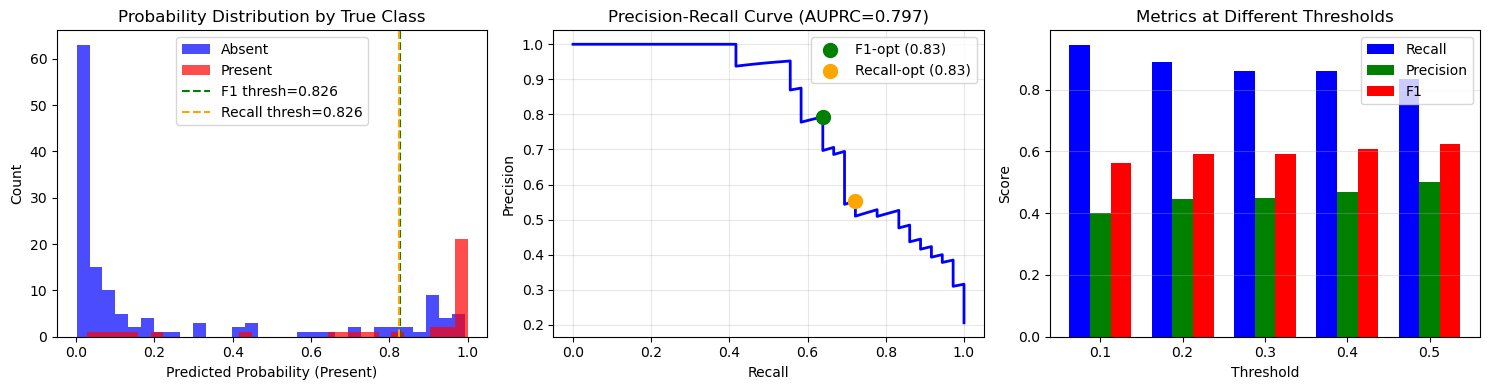

✓ Saved: m3/model3_analysis.png


In [117]:
# Final Results Summary and Visualization
print("\n" + "=" * 60)
print("MODEL 3 FINAL RESULTS - MULTI-MODAL FUSION")
print("=" * 60)

# Calculate metrics at different thresholds for the results dict
from sklearn.metrics import precision_score, recall_score

# Get predictions at optimal threshold
y_pred_f1 = (patient_probs >= best_threshold).astype(int)
precision_f1 = precision_score(patient_labels, y_pred_f1, pos_label=1, zero_division=0)
recall_f1 = recall_score(patient_labels, y_pred_f1, pos_label=1, zero_division=0)
f1_f1 = f1_score(patient_labels, y_pred_f1, pos_label=1, zero_division=0)
accuracy_f1 = (y_pred_f1 == patient_labels).mean()

# Find recall-optimized threshold (target ~70% recall)
fpr, tpr, roc_thresholds = roc_curve(patient_labels, patient_probs)
target_recall = 0.70
valid_mask = tpr >= target_recall
if valid_mask.sum() > 0:
    recall_threshold = float(roc_thresholds[valid_mask][np.argmin(fpr[valid_mask])])
else:
    recall_threshold = 0.3

y_pred_recall = (patient_probs >= recall_threshold).astype(int)
precision_recall = precision_score(patient_labels, y_pred_recall, pos_label=1, zero_division=0)
recall_recall = recall_score(patient_labels, y_pred_recall, pos_label=1, zero_division=0)
f1_recall = f1_score(patient_labels, y_pred_recall, pos_label=1, zero_division=0)
accuracy_recall = (y_pred_recall == patient_labels).mean()

results = {
    'model': 'Model 3: Multi-Modal Fusion (Waveform + Mel Spectrogram)',
    'fusion_type': FUSION_TYPE,
    'train_samples': len(X_train_waveform),
    'train_patients': len(train_patients),
    'test_samples': len(X_test_waveform),
    'test_patients': len(test_patients),
    'waveform_shape': X_train_waveform.shape[1:],
    'melspec_shape': X_train_melspec.shape[1:],
    'cv_auroc_mean': float(mean_auroc),
    'cv_auroc_std': float(std_auroc),
    'cv_auprc_mean': float(mean_auprc),
    'cv_auprc_std': float(std_auprc),
    'thresholds': {
        'f1_optimized': {
            'value': float(best_threshold),
            'precision_present': float(precision_f1),
            'recall_present': float(recall_f1),
            'f1_present': float(f1_f1),
            'accuracy': float(accuracy_f1)
        },
        'recall_optimized': {
            'value': float(recall_threshold),
            'precision_present': float(precision_recall),
            'recall_present': float(recall_recall),
            'f1_present': float(f1_recall),
            'accuracy': float(accuracy_recall)
        }
    },
    'test_metrics': {
        'auroc': float(patient_metrics['auc']),
        'auprc': float(patient_metrics['auprc']),
        'sensitivity': float(patient_metrics['sensitivity']),
        'specificity': float(patient_metrics['specificity'])
    }
}

print(f"\nArchitecture: {FUSION_TYPE.capitalize()} Fusion")
print(f"  - 1D CNN Branch: Raw waveforms ({X_train_waveform.shape[1]} samples)")
print(f"  - 2D CNN Branch: Mel Spectrograms ({N_MELS} mels x {X_train_melspec.shape[2]} time steps)")
print(f"  - Frequency range: 20-1000 Hz")
print(f"\nTraining: {results['train_samples']} recordings from {results['train_patients']} patients")
print(f"Testing: {results['test_samples']} recordings from {results['test_patients']} patients")
print(f"\nCross-Validation:")
print(f"  AUROC: {mean_auroc:.4f} ± {std_auroc:.4f}")
print(f"  AUPRC: {mean_auprc:.4f} ± {std_auprc:.4f}")
print(f"\nTest Performance (Patient-Level):")
print(f"  AUROC: {patient_metrics['auc']:.4f}")
print(f"  AUPRC: {patient_metrics['auprc']:.4f}")

import json

with open('../m3/model3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved: m3/model3_results.json")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Probability Distribution
axes[0].hist(patient_probs[patient_labels == 0], bins=30, alpha=0.7, label='Absent', color='blue')
axes[0].hist(patient_probs[patient_labels == 1], bins=30, alpha=0.7, label='Present', color='red')
axes[0].axvline(x=best_threshold, color='green', linestyle='--', label=f'F1 thresh={best_threshold:.3f}')
axes[0].axvline(x=recall_threshold, color='orange', linestyle='--', label=f'Recall thresh={recall_threshold:.3f}')
axes[0].set_xlabel('Predicted Probability (Present)')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution by True Class')
axes[0].legend()

# Plot 2: Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(patient_labels, patient_probs)
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
optimal_idx = np.argmax(f1_scores[:-1])

# Find index closest to recall threshold
target_idx = np.argmin(np.abs(pr_thresholds - recall_threshold)) if len(pr_thresholds) > 0 else 0

axes[1].plot(recall_curve, precision_curve, 'b-', linewidth=2)
axes[1].scatter(recall_curve[optimal_idx], precision_curve[optimal_idx],
                color='green', s=100, zorder=5, label=f'F1-opt ({best_threshold:.2f})')
if target_idx < len(recall_curve):
    axes[1].scatter(recall_curve[target_idx], precision_curve[target_idx],
                    color='orange', s=100, zorder=5, label=f'Recall-opt ({recall_threshold:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUPRC={patient_metrics["auprc"]:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Metrics at Different Thresholds
thresholds_to_plot = [0.1, 0.2, 0.3, 0.4, 0.5]
recalls = []
precisions = []
f1s = []
for t in thresholds_to_plot:
    y_pred_t = (patient_probs >= t).astype(int)
    r = recall_score(patient_labels, y_pred_t, pos_label=1, zero_division=0)
    p = precision_score(patient_labels, y_pred_t, pos_label=1, zero_division=0)
    f = f1_score(patient_labels, y_pred_t, pos_label=1, zero_division=0)
    recalls.append(r)
    precisions.append(p)
    f1s.append(f)

x = np.arange(len(thresholds_to_plot))
width = 0.25
axes[2].bar(x - width, recalls, width, label='Recall', color='blue')
axes[2].bar(x, precisions, width, label='Precision', color='green')
axes[2].bar(x + width, f1s, width, label='F1', color='red')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Metrics at Different Thresholds')
axes[2].set_xticks(x)
axes[2].set_xticklabels(thresholds_to_plot)
axes[2].legend()
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../m3/model3_analysis.png', dpi=150)
plt.show()
print("✓ Saved: m3/model3_analysis.png")

In [118]:
# Save results
print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)

# Save predictions
np.save('../results/model3_patient_probs.npy', patient_probs)
np.save('../results/model3_patient_labels.npy', patient_labels)
np.save('../results/model3_patient_ids.npy', test_patient_df['patient_id'].values)
np.save('../results/model3_threshold.npy', np.array([best_threshold]))

# Save metrics
metrics_summary = {
    'model': 'Model3_MultiModalFusion',
    'fusion_type': FUSION_TYPE,
    'threshold': best_threshold,
    'patient_auc': patient_metrics['auc'],
    'patient_auprc': patient_metrics['auprc'],
    'patient_f1': patient_metrics['f1'],
    'patient_sensitivity': patient_metrics['sensitivity'],
    'patient_specificity': patient_metrics['specificity'],
    'cv_auroc_mean': mean_auroc,
    'cv_auroc_std': std_auroc,
}
pd.DataFrame([metrics_summary]).to_csv('../m3/model3_metrics.csv', index=False)

print("✓ Results saved to m3/ and results/ directories")


SAVING RESULTS
✓ Results saved to m3/ and results/ directories


In [119]:
# Final Summary
print("\n" + "=" * 60)
print("MODEL 3 COMPLETE")
print("=" * 60)
print(f"\nModel: Multi-Modal Fusion ({FUSION_TYPE})")
print(f"CV AUROC: {mean_auroc:.4f} ± {std_auroc:.4f}")
print(f"Test AUROC: {patient_metrics['auc']:.4f}")
print(f"Test Sensitivity: {patient_metrics['sensitivity']:.4f}")
print(f"Test Specificity: {patient_metrics['specificity']:.4f}")


MODEL 3 COMPLETE

Model: Multi-Modal Fusion (attention)
CV AUROC: 0.8457 ± 0.0476
Test AUROC: 0.9063
Test Sensitivity: 0.6944
Test Specificity: 0.8489
